# Chapter 0 — Visualizing SCF convergence

A short companion notebook to Chapter 0. We parse the reference SCF
output (`code/00-first-scf/ref/gaas.scf.out`) and plot how the
*estimated scf accuracy* falls each iteration — a direct picture of the
self-consistent field loop converging.

Run it after Chapter 0, or just read along. Requirements: `matplotlib`.

In [1]:
import re
from pathlib import Path

# Path to the reference SCF output (relative to this notebook).
out = Path('../code/00-first-scf/ref/gaas.scf.out').read_text()

# Each SCF iteration prints one 'estimated scf accuracy < ... Ry' line.
acc = [float(x) for x in re.findall(r'estimated scf accuracy\s*<\s*([0-9.eE+-]+)\s*Ry', out)]
iters = list(range(1, len(acc) + 1))
for i, a in zip(iters, acc):
    print(f'iteration {i}:  {a:.3e} Ry')

iteration 1:  5.240e-02 Ry
iteration 2:  7.738e-03 Ry
iteration 3:  6.141e-04 Ry
iteration 4:  8.241e-05 Ry
iteration 5:  1.630e-05 Ry
iteration 6:  5.500e-07 Ry
iteration 7:  1.130e-06 Ry
iteration 8:  8.000e-08 Ry
iteration 9:  7.900e-09 Ry
iteration 10:  1.700e-09 Ry
iteration 11:  3.400e-10 Ry
iteration 12:  3.300e-12 Ry
iteration 13:  2.300e-12 Ry
iteration 14:  1.600e-13 Ry
iteration 15:  5.000e-15 Ry
iteration 16:  5.200e-15 Ry
iteration 17:  4.600e-16 Ry
iteration 18:  5.800e-16 Ry
iteration 19:  1.400e-16 Ry
iteration 20:  8.600e-17 Ry
iteration 21:  1.400e-15 Ry
iteration 22:  4.600e-16 Ry
iteration 23:  2.200e-16 Ry
iteration 24:  4.400e-17 Ry
iteration 25:  2.800e-17 Ry
iteration 26:  6.500e-17 Ry
iteration 27:  2.600e-16 Ry
iteration 28:  4.700e-17 Ry
iteration 29:  7.000e-17 Ry
iteration 30:  1.400e-18 Ry
iteration 31:  2.000e-19 Ry
iteration 32:  1.000e-18 Ry
iteration 33:  2.200e-19 Ry
iteration 34:  3.100e-20 Ry
iteration 35:  1.400e-20 Ry
iteration 36:  6.000e-21 Ry


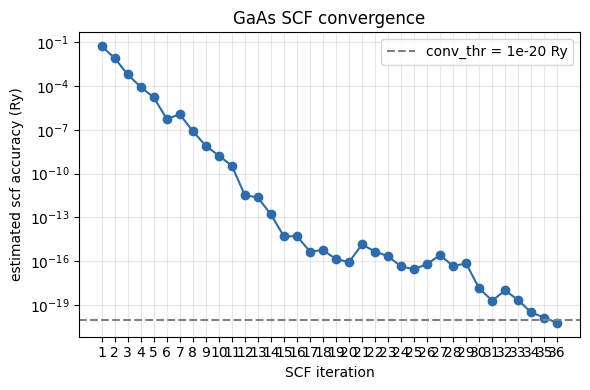

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(iters, acc, 'o-', color='#2b6cb0')
ax.axhline(1e-20, ls='--', color='gray', label='conv_thr = 1e-20 Ry')
ax.set_xlabel('SCF iteration')
ax.set_ylabel('estimated scf accuracy (Ry)')
ax.set_title('GaAs SCF convergence')
ax.set_xticks(iters)
ax.legend()
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()

# Save a copy for the website, then show inline.
out_png = Path('../static/img/00-scf-convergence.png')
out_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_png, dpi=120)
plt.show()

**What you see:** the error falls steeply for the first ~10 iterations,
then flattens onto a noisy plateau near 1e-16–1e-17 Ry — the
floating-point **noise floor**. With a tight `conv_thr = 1e-20`, QE keeps
iterating (36 in total) until the estimate finally dips below the
threshold. The energy is already converged to all printed digits after
~10 steps; the extra iterations buy the precision needed later for forces
and phonons. The SCF need not be monotone — only cross the threshold.